# Earthquake Analysis


In [1]:
# Imported Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Problem Definition and Data Acquisition
Earthquakes are major disasters that can cause severe damage, as well as cause significant harm to people. It is important to understand/examine these events and their significance to better be prepared for future events. 


## EDA + Cleaning + Feature Engineering

In [3]:
df = pd.read_csv("Data/Eartquakes-1990-2023.csv")

print("-----Data Preview-----")
display(df.head())
print("-----Data Info-----")
display(df.info())
print("-----Null Sums-----")
display(df.isnull().sum())
print("-----Data Description-----")
display(df.describe())

-----Data Preview-----


,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00


-----Data Info-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3445751 entries, 0 to 3445750
Data columns (total 12 columns):
 #   Column        Dtype  
---  ------        -----  
 0   time          int64  
 1   place         object 
 2   status        object 
 3   tsunami       int64  
 4   significance  int64  
 5   data_type     object 
 6   magnitudo     float64
 7   state         object 
 8   longitude     float64
 9   latitude      float64
 10  depth         float64
 11  date          object 
dtypes: float64(4), int64(3), object(5)
memory usage: 315.5+ MB


None

-----Null Sums-----


time            0
place           0
status          0
tsunami         0
significance    0
data_type       0
magnitudo       0
state           0
longitude       0
latitude        0
depth           0
date            0
dtype: int64

-----Data Description-----


,time,tsunami,significance,magnitudo,longitude,latitude,depth
count,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06
mean,1.247124e+12,4.434447e-04,7.400973e+01,1.774076e+00,-1.012876e+02,3.746483e+01,2.285387e+01
std,2.976292e+11,2.105346e-02,1.016364e+02,1.291055e+00,7.697416e+01,2.041577e+01,5.484938e+01
min,6.311534e+11,0.000000e+00,0.000000e+00,-9.990000e+00,-1.799997e+02,-8.442200e+01,-1.000000e+01
25%,1.024401e+12,0.000000e+00,1.300000e+01,9.100000e-01,-1.464274e+02,3.406400e+01,3.120000e+00
50%,1.282338e+12,0.000000e+00,3.300000e+01,1.460000e+00,-1.189538e+02,3.793567e+01,7.700000e+00
75%,1.508701e+12,0.000000e+00,8.100000e+01,2.300000e+00,-1.159277e+02,4.784800e+01,1.612000e+01
max,1.690629e+12,1.000000e+00,2.910000e+03,9.100000e+00,1.800000e+02,8.738600e+01,7.358000e+02


#### Feature Engineering: Extracting Time-Based Features
Convert the 'date' column to datetime format. This extracts the features such as year, month, day, and time. These new features are important for analyzing and visualizing the data.

In [4]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
display(df.isnull().sum())
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour #0(midnight) - 23 (11PM)

print("-----DataFrame sample with new features-----")
display(df.head())
print("-----Null Sums-----")
display(df.isnull().sum())

time                0
place               0
status              0
tsunami             0
significance        0
data_type           0
magnitudo           0
state               0
longitude           0
latitude            0
depth               0
date            46953
dtype: int64

-----DataFrame sample with new features-----


,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date,year,month,day,hour
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00,1990.0,1.0,1.0,0.0
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00,1990.0,1.0,1.0,0.0
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00,1990.0,1.0,1.0,0.0
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00,1990.0,1.0,1.0,0.0
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00,1990.0,1.0,1.0,1.0


-----Null Sums-----


time                0
place               0
status              0
tsunami             0
significance        0
data_type           0
magnitudo           0
state               0
longitude           0
latitude            0
depth               0
date            46953
year            46953
month           46953
day             46953
hour            46953
dtype: int64

#### Handling Null Values in Date-Related Columns

Since pd.to_datetime with errors='coerce' introduced NaT values for unparseable dates.

For analysis, rows with missing date information are often not useful. Therefore, we will drop these rows.

In [5]:
print("-----Nulls before dropping rows with missing date-----")
display(df[['date', 'year', 'month', 'day', 'hour']].isnull().sum())

# Drop rows where 'date' is NaT (Not a Time)
df_cleaned = df.dropna(subset=['date']).copy()

print("\n-----Nulls after dropping rows with missing date-----")
display(df_cleaned[['date', 'year', 'month', 'day', 'hour']].isnull().sum())
print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

df = df_cleaned # Update the main DataFrame to the cleaned version

-----Nulls before dropping rows with missing date-----


date     46953
year     46953
month    46953
day      46953
hour     46953
dtype: int64


-----Nulls after dropping rows with missing date-----


date     0
year     0
month    0
day      0
hour     0
dtype: int64


Original DataFrame shape: (3445751, 16)
Cleaned DataFrame shape: (3398798, 16)


#### Drop Status Column
This column does not give information that is that useful for analysis, so I am dropping it from the dataframe.

In [6]:
df['status'].value_counts()
df = df.drop('status', axis=1)
df.head()

,time,place,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date,year,month,day,hour
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00,1990.0,1.0,1.0,0.0
1,631153491210,"14 km S of Volcano, Hawaii",0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00,1990.0,1.0,1.0,0.0
2,631154083450,"7 km W of Cobb, California",0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00,1990.0,1.0,1.0,0.0
3,631155512130,"11 km E of Mammoth Lakes, California",0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00,1990.0,1.0,1.0,0.0
4,631155824490,"16km N of Fillmore, CA",0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00,1990.0,1.0,1.0,1.0


#### Rename Magnitudo Column
I renamed the mangitudo column to magnitude for ease of understanding and cleaning.

In [7]:
df = df.rename(columns={'magnitudo': 'magnitude'})
df.head()

,time,place,tsunami,significance,data_type,magnitude,state,longitude,latitude,depth,date,year,month,day,hour
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00,1990.0,1.0,1.0,0.0
1,631153491210,"14 km S of Volcano, Hawaii",0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00,1990.0,1.0,1.0,0.0
2,631154083450,"7 km W of Cobb, California",0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00,1990.0,1.0,1.0,0.0
3,631155512130,"11 km E of Mammoth Lakes, California",0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00,1990.0,1.0,1.0,0.0
4,631155824490,"16km N of Fillmore, CA",0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00,1990.0,1.0,1.0,1.0


#### Cleaning: Drop Columns
* Drop the place column as it is not useful for modeling since it is just free text. Also already have longitude and latitude.  
* Drop the data_type column since it is basically all labeled as earthquakes, and it is not very useful.  
* Drop the state column as it is inconsistent with its labeling and longitude and latitude are already present.  
* Drop the date column since year/month/day/hour have already been extracted.
* Drop the time column since it gives irrelevant information.



In [8]:
df = df.drop(columns=['time', 'place', 'data_type', 'state', 'date'])
df.head()

,tsunami,significance,magnitude,longitude,latitude,depth,year,month,day,hour
0,0,96,2.50,-149.669200,61.730200,30.100,1990.0,1.0,1.0,0.0
1,0,31,1.41,-155.212333,19.317667,6.585,1990.0,1.0,1.0,0.0
2,0,19,1.11,-122.806167,38.821000,3.220,1990.0,1.0,1.0,0.0
3,0,15,0.98,-118.846333,37.664333,-0.584,1990.0,1.0,1.0,0.0
4,0,134,2.95,-118.934000,34.546000,16.122,1990.0,1.0,1.0,1.0


#### Rename significance to sig
This just makes it easier to use in the future to use.

In [9]:
df = df.rename(columns={'significance': 'sig'})
display(df.head())

,tsunami,sig,magnitude,longitude,latitude,depth,year,month,day,hour
0,0,96,2.50,-149.669200,61.730200,30.100,1990.0,1.0,1.0,0.0
1,0,31,1.41,-155.212333,19.317667,6.585,1990.0,1.0,1.0,0.0
2,0,19,1.11,-122.806167,38.821000,3.220,1990.0,1.0,1.0,0.0
3,0,15,0.98,-118.846333,37.664333,-0.584,1990.0,1.0,1.0,0.0
4,0,134,2.95,-118.934000,34.546000,16.122,1990.0,1.0,1.0,1.0


In [10]:
df['sig'].describe()

count    3.398798e+06
mean     7.331222e+01
std      1.012990e+02
min      0.000000e+00
25%      1.200000e+01
50%      3.200000e+01
75%      7.800000e+01
max      2.910000e+03
Name: sig, dtype: float64

#### Visualizations

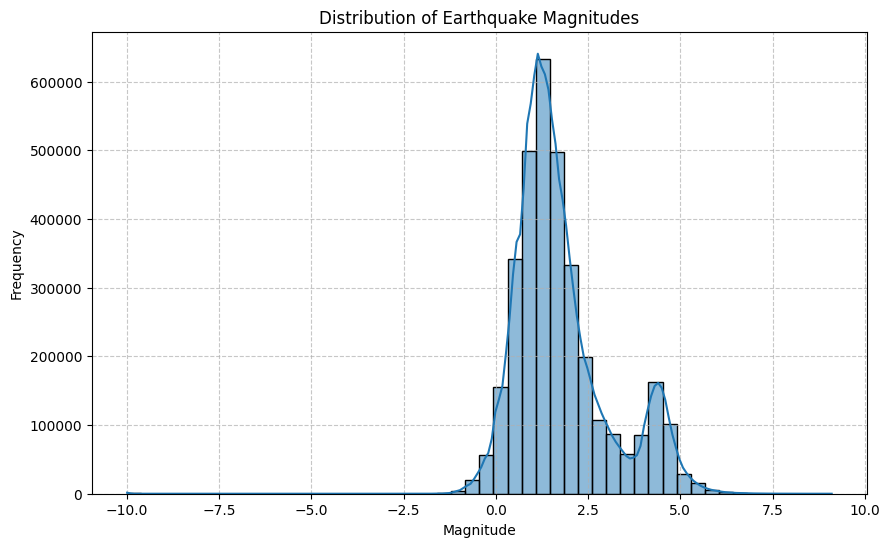

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['magnitude'], kde=True, bins=50)
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Magnitude calculations are based on a logarithmic scale, so a ten-fold drop in amplitude decreases the magnitude by 1.
An earthquake of negative magnitude is a very small earthquake that is not felt by humans.  
-USGS.GOV

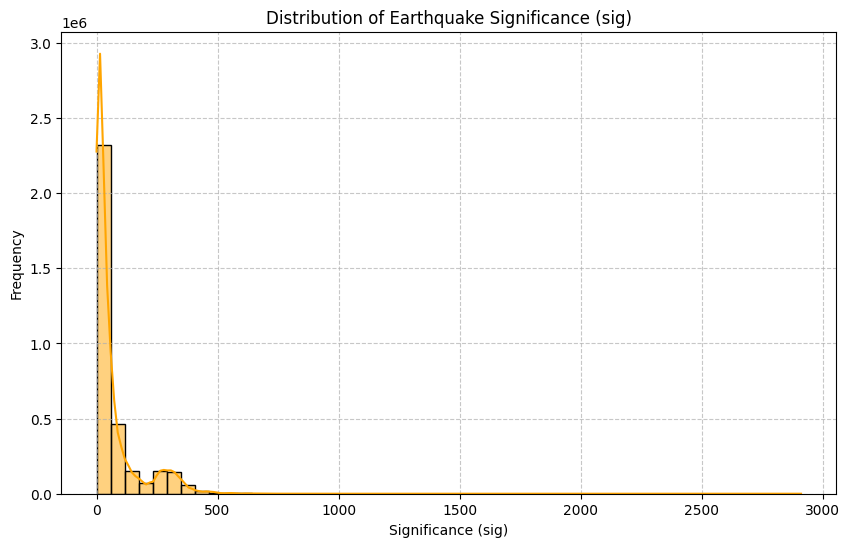

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sig'], kde=True, bins=50, color='orange')
plt.title('Distribution of Earthquake Significance (sig)')
plt.xlabel('Significance (sig)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\cjmer\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


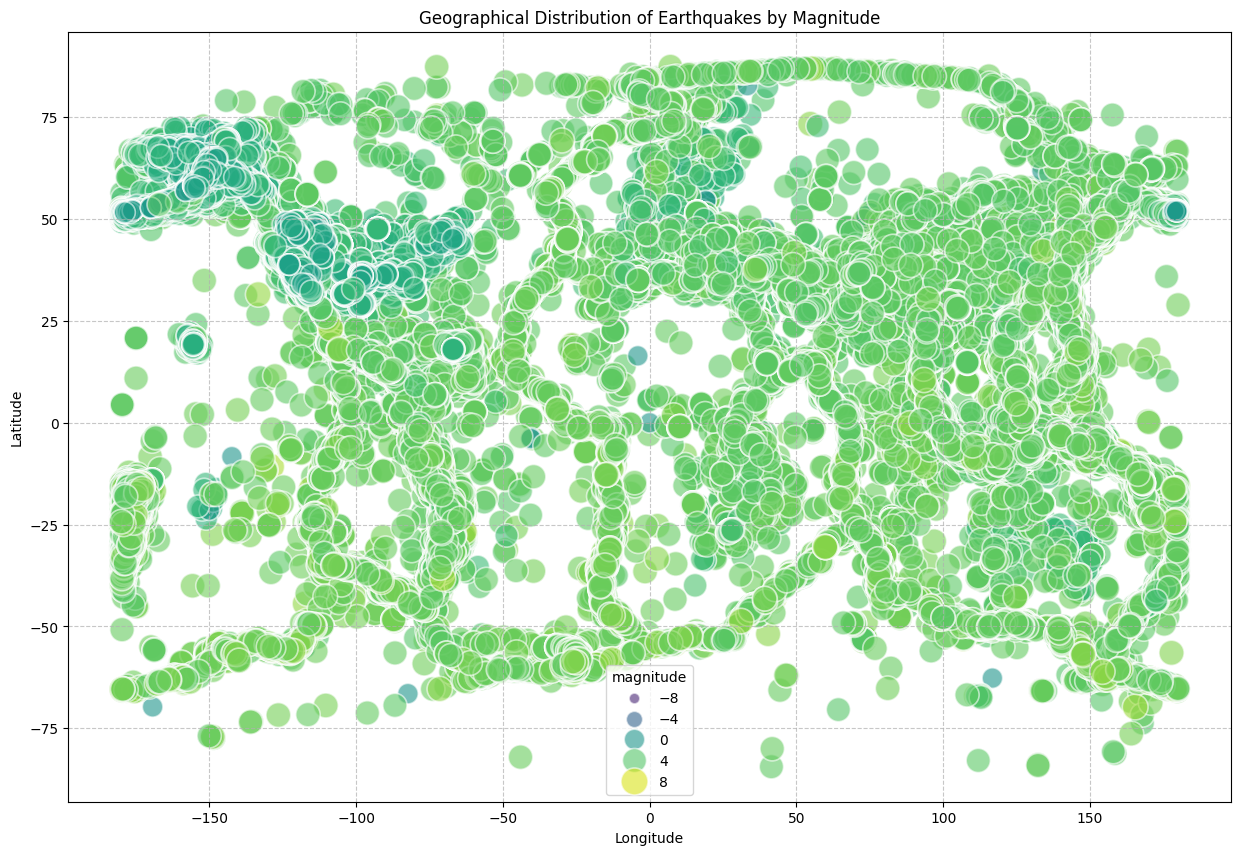

In [13]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x='longitude', y='latitude', hue='magnitude', size='magnitude', sizes=(20, 400), palette='viridis', alpha=0.6, data=df)
plt.title('Geographical Distribution of Earthquakes by Magnitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

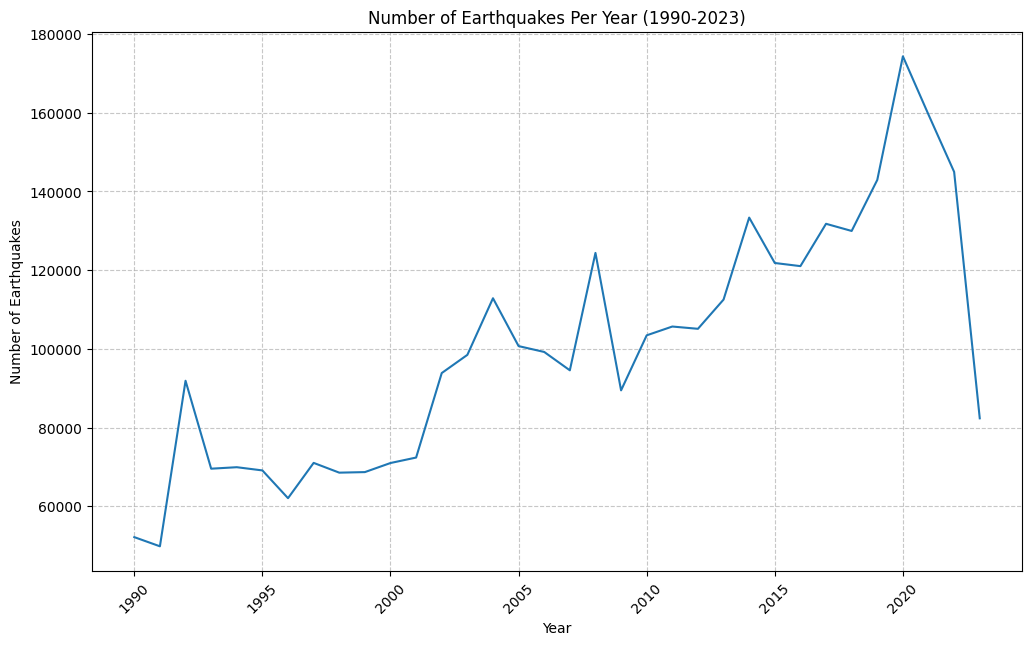

In [14]:
earthquakes_per_year = df['year'].value_counts().sort_index().reset_index()
earthquakes_per_year.columns = ['year', 'count']

plt.figure(figsize=(12, 7))
sns.lineplot(x='year', y='count', data=earthquakes_per_year)
plt.title('Number of Earthquakes Per Year (1990-2023)')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

#### Feature: depth_category

In [15]:
def depth_category(depth):
  if depth < 70:
    return 'shallow'
  elif depth < 300:
    return 'intermediate'
  else:
    return 'deep'

df['depth_category'] = df['depth'].apply(depth_category)

print(df['depth_category'].value_counts())

depth_dummies = pd.get_dummies(df['depth_category'], prefix='depth')
df = pd.concat([df, depth_dummies], axis=1)

depth_category
shallow         3115005
intermediate     255556
deep              28237
Name: count, dtype: int64


In [16]:
df.head()

,tsunami,sig,magnitude,longitude,latitude,depth,year,month,day,hour,depth_category,depth_deep,depth_intermediate,depth_shallow
0,0,96,2.50,-149.669200,61.730200,30.100,1990.0,1.0,1.0,0.0,shallow,False,False,True
1,0,31,1.41,-155.212333,19.317667,6.585,1990.0,1.0,1.0,0.0,shallow,False,False,True
2,0,19,1.11,-122.806167,38.821000,3.220,1990.0,1.0,1.0,0.0,shallow,False,False,True
3,0,15,0.98,-118.846333,37.664333,-0.584,1990.0,1.0,1.0,0.0,shallow,False,False,True
4,0,134,2.95,-118.934000,34.546000,16.122,1990.0,1.0,1.0,1.0,shallow,False,False,True


#### Feature: magnitude_energy
The Richter scale is logarithmic, so we should do the conversion to get raw energy, as this will better for a model to see how significant the differences are in energy.

For example, a magnitude of 3.0 would be ~31,623 Joules while a magnitude of 5.0 would be ~31.6 million Joules.

In [17]:
#Convert from log scale (magnitude) to linear energy (magnitude_energy)
df['magnitude_energy'] = 10 ** (1.5 ** df['magnitude'])
df.sample(10)

,tsunami,sig,magnitude,longitude,latitude,depth,year,month,day,hour,depth_category,depth_deep,depth_intermediate,depth_shallow,magnitude_energy
2804652,0,44,1.70,-147.804800,61.965500,33.500,2019.0,6.0,26.0,7.0,shallow,False,False,True,98.243055
1310936,0,211,3.70,22.440000,35.540000,58.000,2006.0,9.0,8.0,0.0,shallow,False,False,True,30386.395404
81404,0,30,1.40,-115.942167,33.150333,0.924,1991.0,7.0,24.0,16.0,shallow,False,False,True,58.092295
3018087,0,97,2.51,-67.061800,17.936000,11.000,2020.0,10.0,11.0,12.0,shallow,False,False,True,584.617683
3209320,0,24,1.24,-122.579000,38.489000,9.960,2021.0,12.0,9.0,1.0,shallow,False,False,True,45.009656
1717884,0,1,0.27,-122.810833,38.791333,3.274,2010.0,8.0,5.0,7.0,shallow,False,False,True,13.052474
552630,0,19,1.12,-116.638000,33.421000,5.237,1998.0,2.0,15.0,17.0,shallow,False,False,True,37.565434
2868792,0,0,-0.46,-154.982167,58.311500,0.700,2019.0,11.0,29.0,3.0,shallow,False,False,True,6.758448
2288904,0,11,0.85,-122.819000,38.821499,2.019,2015.0,6.0,29.0,10.0,shallow,False,False,True,25.792250
3069053,0,79,2.27,-155.479000,19.435333,6.950,2021.0,1.0,25.0,19.0,shallow,False,False,True,323.823867


In [18]:
df["magnitude_energy"].describe()

count    3.398798e+06
mean     6.365698e+33
std      8.298278e+36
min      1.040907e+00
25%      2.756746e+01
50%      6.313177e+01
75%      3.090540e+02
max      1.081772e+40
Name: magnitude_energy, dtype: float64

#### Feature: ring_of_fire
Binary flag - is this earthquake located in the Pacific Ring of Fire or not?

In [19]:
def in_ring_of_fire(lat, lon):
    return int((-60 <= lat <= 70) and (lon >= 120 or lon <= -60))

df["ring_of_fire"] = df.apply(
    lambda r: in_ring_of_fire(r["latitude"], r["longitude"]), axis=1
)

print(f"Ring of Fire events : {df['ring_of_fire'].sum():,}")
print(f"Percentage          : {df['ring_of_fire'].mean()*100:.1f}%")

Ring of Fire events : 3,192,869
Percentage          : 93.9%


#### Feature: local_event_density
Count of how many earthquakes happened in a 5° x 5 box of lat/lon. Useful for clustering. Will give the model a sense of whether an earthquake is common or uncommon in certain regions.

In [20]:
df["lat_grid"] = (df["latitude"]  // 5) * 5
df["lon_grid"] = (df["longitude"] // 5) * 5

# Count events per grid cell, then join back
density_map = (
    df.groupby(["lat_grid", "lon_grid"])
    .size()
    .rename("local_event_density")
)
df = df.join(density_map, on=["lat_grid", "lon_grid"])

print(df["local_event_density"].describe())

# Drop the helper columns — we only need the density value
df.drop(columns=["lat_grid", "lon_grid"], inplace=True)

count    3.398798e+06
mean     2.687421e+05
std      2.277383e+05
min      1.000000e+00
25%      3.700800e+04
50%      2.106900e+05
75%      5.052660e+05
max      5.750800e+05
Name: local_event_density, dtype: float64


In [21]:
df.sample(5)

,tsunami,sig,magnitude,longitude,latitude,depth,year,month,day,hour,depth_category,depth_deep,depth_intermediate,depth_shallow,magnitude_energy,ring_of_fire,local_event_density
1056063,0,15,1.00,-115.828800,36.622300,10.100,2004.0,4.0,17.0,7.0,shallow,False,False,True,31.622777,1,575080
470947,0,38,1.57,-117.635000,36.061000,1.475,1997.0,1.0,12.0,13.0,shallow,False,False,True,77.625857,1,575080
125904,0,129,2.90,-155.138667,19.320667,8.829,1992.0,5.0,3.0,6.0,shallow,False,False,True,1741.376543,1,119983
2762930,0,168,3.30,-148.710400,56.447700,20.690,2019.0,3.0,12.0,20.0,shallow,False,False,True,6479.565840,1,7280
475946,0,20,1.13,-117.635000,36.054000,1.067,1997.0,2.0,9.0,4.0,shallow,False,False,True,38.122958,1,575080


#### Feature: sig_per_mag
Significance normalized by magnitude.
Significance of an earthquake measures the impact it had, such as the severity of shaking, damage, and injuries.  
A higher value means that earthquake caused more of an impact than its raw energy would suggest.  
(Important for events that happen in the ocean)

In [22]:
# High value = event caused more impact than its raw energy would suggest
df["sig_per_mag"] = df["sig"] / (df["magnitude"] + 1e-6)

print(df["sig_per_mag"].describe())

count    3.398798e+06
mean     3.706552e+01
std      4.373126e+03
min     -1.310131e+04
25%      1.379309e+01
50%      2.222221e+01
75%      3.466665e+01
max      4.000000e+06
Name: sig_per_mag, dtype: float64


#### Clean Data

In [23]:
print("-----Data Preview-----")
display(df.head())
print("-----Data Info-----")
display(df.info())
print("-----Null Sums-----")
display(df.isnull().sum())
print("-----Data Description-----")
display(df.describe())

-----Data Preview-----


,tsunami,sig,magnitude,longitude,latitude,depth,year,month,day,hour,depth_category,depth_deep,depth_intermediate,depth_shallow,magnitude_energy,ring_of_fire,local_event_density,sig_per_mag
0,0,96,2.50,-149.669200,61.730200,30.100,1990.0,1.0,1.0,0.0,shallow,False,False,True,569.739015,1,207391,38.399985
1,0,31,1.41,-155.212333,19.317667,6.585,1990.0,1.0,1.0,0.0,shallow,False,False,True,59.058980,1,119983,21.985800
2,0,19,1.11,-122.806167,38.821000,3.220,1990.0,1.0,1.0,0.0,shallow,False,False,True,37.018270,1,505266,17.117102
3,0,15,0.98,-118.846333,37.664333,-0.584,1990.0,1.0,1.0,0.0,shallow,False,False,True,30.752840,1,575080,15.306107
4,0,134,2.95,-118.934000,34.546000,16.122,1990.0,1.0,1.0,1.0,shallow,False,False,True,2028.928163,1,431525,45.423713


-----Data Info-----
<class 'pandas.core.frame.DataFrame'>
Index: 3398798 entries, 0 to 3445750
Data columns (total 18 columns):
 #   Column               Dtype  
---  ------               -----  
 0   tsunami              int64  
 1   sig                  int64  
 2   magnitude            float64
 3   longitude            float64
 4   latitude             float64
 5   depth                float64
 6   year                 float64
 7   month                float64
 8   day                  float64
 9   hour                 float64
 10  depth_category       object 
 11  depth_deep           bool   
 12  depth_intermediate   bool   
 13  depth_shallow        bool   
 14  magnitude_energy     float64
 15  ring_of_fire         int64  
 16  local_event_density  int64  
 17  sig_per_mag          float64
dtypes: bool(3), float64(10), int64(4), object(1)
memory usage: 424.6+ MB


None

-----Null Sums-----


tsunami                0
sig                    0
magnitude              0
longitude              0
latitude               0
depth                  0
year                   0
month                  0
day                    0
hour                   0
depth_category         0
depth_deep             0
depth_intermediate     0
depth_shallow          0
magnitude_energy       0
ring_of_fire           0
local_event_density    0
sig_per_mag            0
dtype: int64

-----Data Description-----


,tsunami,sig,magnitude,longitude,latitude,depth,year,month,day,hour,magnitude_energy,ring_of_fire,local_event_density,sig_per_mag
count,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06,3.398798e+06
mean,4.430978e-04,7.331222e+01,1.764227e+00,-1.017242e+02,3.759232e+01,2.281361e+01,2.009036e+03,6.492238e+00,1.532591e+01,1.143877e+01,6.365698e+33,9.394112e-01,2.687421e+05,3.706552e+01
std,2.104523e-02,1.012990e+02,1.287175e+00,7.671800e+01,2.029139e+01,5.491453e+01,9.453783e+00,3.430573e+00,8.680055e+00,6.902006e+00,8.298278e+36,2.385745e-01,2.277383e+05,4.373126e+03
min,0.000000e+00,0.000000e+00,-9.990000e+00,-1.799997e+02,-8.442200e+01,-1.000000e+01,1.990000e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.040907e+00,0.000000e+00,1.000000e+00,-1.310131e+04
25%,0.000000e+00,1.200000e+01,9.000000e-01,-1.465869e+02,3.409100e+01,3.106000e+00,2.002000e+03,4.000000e+00,8.000000e+00,5.000000e+00,2.756746e+01,1.000000e+00,3.700800e+04,1.379309e+01
50%,0.000000e+00,3.200000e+01,1.450000e+00,-1.190048e+02,3.796867e+01,7.700000e+00,2.010000e+03,7.000000e+00,1.500000e+01,1.100000e+01,6.313177e+01,1.000000e+00,2.106900e+05,2.222221e+01
75%,0.000000e+00,7.800000e+01,2.250000e+00,-1.160313e+02,4.805015e+01,1.602000e+01,2.017000e+03,9.000000e+00,2.300000e+01,1.700000e+01,3.090540e+02,1.000000e+00,5.052660e+05,3.466665e+01
max,1.000000e+00,2.910000e+03,9.100000e+00,1.800000e+02,8.738600e+01,7.358000e+02,2.023000e+03,1.200000e+01,3.000000e+01,2.300000e+01,1.081772e+40,1.000000e+00,5.750800e+05,4.000000e+06


In [24]:
new_features = [
    "depth_category", "depth_shallow", "depth_intermediate", "depth_deep",
    "magnitude_energy", "ring_of_fire", "local_event_density", "sig_per_mag"
]
df[new_features].head()

,depth_category,depth_shallow,depth_intermediate,depth_deep,magnitude_energy,ring_of_fire,local_event_density,sig_per_mag
0,shallow,True,False,False,569.739015,1,207391,38.399985
1,shallow,True,False,False,59.058980,1,119983,21.985800
2,shallow,True,False,False,37.018270,1,505266,17.117102
3,shallow,True,False,False,30.752840,1,575080,15.306107
4,shallow,True,False,False,2028.928163,1,431525,45.423713


In [25]:
df.head()

,tsunami,sig,magnitude,longitude,latitude,depth,year,month,day,hour,depth_category,depth_deep,depth_intermediate,depth_shallow,magnitude_energy,ring_of_fire,local_event_density,sig_per_mag
0,0,96,2.50,-149.669200,61.730200,30.100,1990.0,1.0,1.0,0.0,shallow,False,False,True,569.739015,1,207391,38.399985
1,0,31,1.41,-155.212333,19.317667,6.585,1990.0,1.0,1.0,0.0,shallow,False,False,True,59.058980,1,119983,21.985800
2,0,19,1.11,-122.806167,38.821000,3.220,1990.0,1.0,1.0,0.0,shallow,False,False,True,37.018270,1,505266,17.117102
3,0,15,0.98,-118.846333,37.664333,-0.584,1990.0,1.0,1.0,0.0,shallow,False,False,True,30.752840,1,575080,15.306107
4,0,134,2.95,-118.934000,34.546000,16.122,1990.0,1.0,1.0,1.0,shallow,False,False,True,2028.928163,1,431525,45.423713


#### Features for training

In [26]:
#Features to be used in DBSCAN Clustering
cluster_features = [
    "latitude", "longitude", "depth", "magnitude",
    "tsunami", "hour", "month",
    "magnitude_energy", "ring_of_fire", "local_event_density",
    "depth_shallow", "depth_intermediate", "depth_deep",
]

# Features for Random Forest (same + sig_per_mag)
RF_FEATURES = cluster_features + ["sig_per_mag"]


#### DBSCAN Clustering (Model 1)
Density-Based Spatial Clustering of Applications with Noise

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

print(f"Scaled feature matrix shape: {X_scaled.shape}")

Scaled feature matrix shape: (3398798, 13)


In [28]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"PCA 2D explained variance: {pca_2d.explained_variance_ratio_.sum():.2%}")

pca_full = PCA(n_components=0.95, random_state=42)
X_pca = pca_full.fit_transform(X_scaled)

print(f"PCA 95% components: {X_pca.shape[1]}")
print(f"Variance retained: {pca_full.explained_variance_ratio_.sum():.2%}")

PCA 2D explained variance: 40.89%
PCA 95% components: 10
Variance retained: 97.27%


In [29]:
SAMPLE_SIZE = 50_000
np.random.seed(42)

if len(X_pca) > SAMPLE_SIZE:
    idx_sample = np.random.choice(len(X_pca), SAMPLE_SIZE, replace=False)
    X_cluster = X_pca[idx_sample]
    X_cluster_2d = X_pca_2d[idx_sample]
    df_cluster = df.iloc[idx_sample].copy()
    print(f"Subsampled to {SAMPLE_SIZE:,} events for clustering")
else:
    X_cluster = X_pca
    X_cluster_2d = X_pca_2d
    df_cluster = df.copy()
    print(f"Using full dataset ({len(X_pca):,} events) for clustering")

Subsampled to 50,000 events for clustering


In [30]:
eps_values = [0.3, 0.5, 0.8, 1.0, 1.5]
results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=10, n_jobs=-1)
    labels = dbscan.fit_predict(X_cluster)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100

    if n_clusters > 1:
        mask = labels != -1
        sil = silhouette_score(X_cluster[mask], labels[mask], sample_size=5000)
    else:
        sil = None

    results.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "noise_%": round(noise_pct, 1),
        "silhouette": sil
    })
    print(f"  eps={eps:.1f} → clusters={n_clusters}, noise={noise_pct:.1f}%, silhouette={sil}")

results_df = pd.DataFrame(results)
results_df

  eps=0.3 → clusters=107, noise=30.6%, silhouette=-0.03808806962555466
  eps=0.5 → clusters=36, noise=8.6%, silhouette=0.22359911102488686
  eps=0.8 → clusters=16, noise=2.2%, silhouette=0.49109727792689867
  eps=1.0 → clusters=12, noise=1.0%, silhouette=0.31360892838541765
  eps=1.5 → clusters=10, noise=0.2%, silhouette=0.49901392729675126


,eps,n_clusters,noise_%,silhouette
0,0.3,107,30.6,-0.038088
1,0.5,36,8.6,0.223599
2,0.8,16,2.2,0.491097
3,1.0,12,1.0,0.313609
4,1.5,10,0.2,0.499014


Entry 3 in the table is the best. eps=1.0. It has the highest silhouette score (anything above 4.0 is good), only 1% of noise (almost everything gets assigned to a cluster), and 11 clusters (not too fragmented, reasonable amount of clusters).

In [31]:
# Fit final DBSCAN with best eps
best_eps = 1.0

dbscan_final = DBSCAN(eps=best_eps, min_samples=10, n_jobs=-1)
cluster_labels = dbscan_final.fit_predict(X_cluster)

df_cluster["cluster_label"] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()
noise_pct = n_noise / len(cluster_labels) * 100

print(f"Final DBSCAN clustering:")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {n_noise:,} ({noise_pct:.1f}%)")
print(f"\nCluster size distribution:")
print(df_cluster["cluster_label"].value_counts().sort_index())

Final DBSCAN clustering:
  Clusters found: 12
  Noise points: 520 (1.0%)

Cluster size distribution:
cluster_label
-1       520
 0      2050
 1     40925
 2      2224
 3      2779
 4       643
 5       215
 6       486
 7        98
 8        17
 9        19
 10       14
 11       10
Name: count, dtype: int64


This data shows around a couple major cluster zones (zone 0 especially, as well as zone 1 and 2), and a bunch of smaller more specialized clusters.

In [32]:
mask = cluster_labels != -1
sil_score = silhouette_score(X_cluster[mask], cluster_labels[mask], sample_size=5000, random_state=42)
db_score = davies_bouldin_score(X_cluster[mask], cluster_labels[mask])

print(f"Clustering metrics:")
print(f"  Silhouette score     : {sil_score:.4f}  (higher = better, max 1.0)")
print(f"  Davies-Bouldin index : {db_score:.4f}   (lower = better)")

Clustering metrics:
  Silhouette score     : 0.2592  (higher = better, max 1.0)
  Davies-Bouldin index : 0.9311   (lower = better)


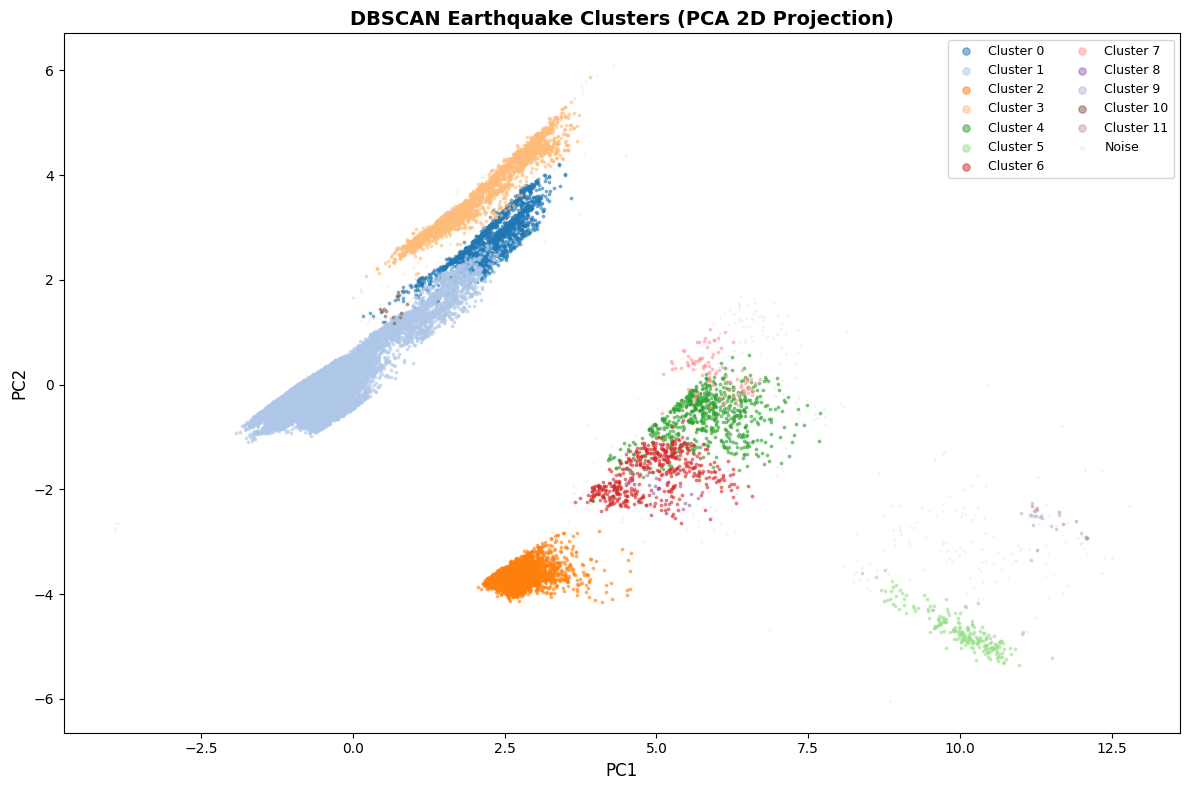

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))

unique_clusters = sorted(set(cluster_labels[cluster_labels != -1]))
colors = plt.cm.tab20.colors

for cluster_id in unique_clusters:
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_cluster_2d[mask, 0],
        X_cluster_2d[mask, 1],
        s=3, alpha=0.5,
        color=colors[cluster_id % 20],
        label=f"Cluster {cluster_id}"
    )

noise_mask = cluster_labels == -1
ax.scatter(
    X_cluster_2d[noise_mask, 0],
    X_cluster_2d[noise_mask, 1],
    s=1, alpha=0.2, color="lightgray", label="Noise"
)

ax.set_xlabel("PC1", fontsize=12)
ax.set_ylabel("PC2", fontsize=12)
ax.set_title("DBSCAN Earthquake Clusters (PCA 2D Projection)", fontsize=14, fontweight="bold")
ax.legend(markerscale=3, fontsize=9, loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

Visual separation looks good, and clusters do not heavily overlap.  
###### Clusters Geographically

In [34]:
profile_cols = ["magnitude", "depth", "latitude", "longitude", "sig"]

cluster_profile = (
    df_cluster[df_cluster["cluster_label"] != -1]
    .groupby("cluster_label")[profile_cols]
    .mean()
    .round(2)
)

print("Cluster mean profiles:")
cluster_profile

Cluster mean profiles:


,magnitude,depth,latitude,longitude,sig
cluster_label,,,,,
0,4.40,29.03,13.82,147.10,306.14
1,1.41,9.84,40.19,-126.49,44.22
2,1.81,101.42,60.54,-153.41,55.85
3,3.54,15.17,26.72,33.09,212.70
4,4.31,130.52,8.50,144.93,293.37
5,4.41,537.00,-20.13,-178.55,300.54
6,3.76,123.81,-8.42,-72.15,225.51
7,4.21,140.50,35.48,69.06,282.89
8,4.53,144.92,-22.32,-176.11,317.18


Based on latitude and longitude, the clustering found real structure. It was able to separate shallow from deep events and group by geography.   
Cluster 0 = Ring of Fire shallow events (Includes California), many low mag events.  
Cluster 3,5,6,9,10 = deep zones at different locations worldwide  
Cluster 2, 4 = shallow, intermediate plate boundaries.

#### Random Forest Classifier (Model 2)

In [35]:
#Create sig labels low/medium/high
df["sig_label"] = pd.qcut(
    df["sig"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Significance label distribution:")
print(df["sig_label"].value_counts())
print("\nSig ranges per class:")
print(df.groupby("sig_label")["sig"].agg(["min", "max"]))

Significance label distribution:
sig_label
low       1189762
medium    1107396
high      1101640
Name: count, dtype: int64

Sig ranges per class:
           min   max
sig_label           
low          0    19
medium      20    56
high        57  2910


C:\Users\cjmer\AppData\Local\Temp\ipykernel_19412\3295095150.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("sig_label")["sig"].agg(["min", "max"]))


In [36]:
X_rf = df[RF_FEATURES].dropna()
y_rf = df.loc[X_rf.index, "sig_label"]

print(f"Feature matrix shape: {X_rf.shape}")
print(f"Target distribution:\n{y_rf.value_counts()}")

# Encode labels to integers (low=0, medium=1, high=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y_rf)

print(f"\nLabel mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Feature matrix shape: (3398798, 14)
Target distribution:
sig_label
low       1189762
medium    1107396
high      1101640
Name: count, dtype: int64

Label mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [37]:
# Train / val / test split (60% / 20% / 20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_rf, y_encoded,
    test_size=0.40,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {len(X_train):,}")
print(f"Val:   {len(X_val):,}")
print(f"Test:  {len(X_test):,}")

Train: 2,039,278
Val:   679,760
Test:  679,760


###### Scale the features

In [38]:
scaler_rf = StandardScaler()
X_train_scaled = scaler_rf.fit_transform(X_train)
X_val_scaled = scaler_rf.transform(X_val)
X_test_scaled = scaler_rf.transform(X_test)

In [39]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_baseline.fit(X_train_scaled, y_train)

val_preds = rf_baseline.predict(X_val_scaled)
val_acc = accuracy_score(y_val, val_preds)

print(f"\nBaseline validation accuracy: {val_acc:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.4min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.3s



Baseline validation accuracy: 1.0000


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.1s finished


Accuracy of 1.0 doesn't seem right? Assuming there might be a data leak. Going to try again with different features.

In [40]:
RF_FEATURES_CLEAN = [f for f in RF_FEATURES if f != "sig_per_mag"]

print(f"Features without sig_per_mag: {RF_FEATURES_CLEAN}")
print(f"Count: {len(RF_FEATURES_CLEAN)}")

Features without sig_per_mag: ['latitude', 'longitude', 'depth', 'magnitude', 'tsunami', 'hour', 'month', 'magnitude_energy', 'ring_of_fire', 'local_event_density', 'depth_shallow', 'depth_intermediate', 'depth_deep']
Count: 13


In [41]:
X_rf_clean = df[RF_FEATURES_CLEAN].dropna()
y_rf_clean = df.loc[X_rf_clean.index, "sig_label"]

y_encoded_clean = le.fit_transform(y_rf_clean)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_rf_clean, y_encoded_clean,
    test_size=0.40,
    random_state=42,
    stratify=y_encoded_clean
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

scaler_rf = StandardScaler()
X_train_scaled = scaler_rf.fit_transform(X_train)
X_val_scaled = scaler_rf.transform(X_val)
X_test_scaled = scaler_rf.transform(X_test)

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)

val_acc = accuracy_score(y_val, rf_baseline.predict(X_val_scaled))
print(f"Validation accuracy (without sig_per_mag): {val_acc:.4f}")

Validation accuracy (without sig_per_mag): 0.9999


In [42]:
print("Features being used:")
for i, feat in enumerate(RF_FEATURES_CLEAN, 1):
    print(f"  {i}. {feat}")

Features being used:
  1. latitude
  2. longitude
  3. depth
  4. magnitude
  5. tsunami
  6. hour
  7. month
  8. magnitude_energy
  9. ring_of_fire
  10. local_event_density
  11. depth_shallow
  12. depth_intermediate
  13. depth_deep


In [43]:
# Check all columns with 'sig' in the name
sig_cols = [col for col in df.columns if 'sig' in col.lower()]
print(f"\nAll columns with 'sig' in name: {sig_cols}")


All columns with 'sig' in name: ['sig', 'sig_per_mag', 'sig_label']


In [44]:
from sklearn.metrics import classification_report, confusion_matrix

val_preds = rf_baseline.predict(X_val_scaled)

# Confusion matrix
cm = confusion_matrix(y_val, val_preds)
print("Confusion matrix:")
print(cm)

# Classification report
print("\nClassification report:")
print(classification_report(y_val, val_preds, target_names=le.classes_))

# Check: how many are actually wrong?
n_wrong = (y_val != val_preds).sum()
print(f"\nMisclassified: {n_wrong} out of {len(y_val)} ({n_wrong/len(y_val)*100:.2f}%)")

Confusion matrix:
[[220281      0     47]
 [     0 237952      0]
 [     0     10 221470]]

Classification report:
              precision    recall  f1-score   support

        high       1.00      1.00      1.00    220328
         low       1.00      1.00      1.00    237952
      medium       1.00      1.00      1.00    221480

    accuracy                           1.00    679760
   macro avg       1.00      1.00      1.00    679760
weighted avg       1.00      1.00      1.00    679760


Misclassified: 57 out of 679760 (0.01%)


In [45]:
# Feature importance
importances = rf_baseline.feature_importances_
feat_imp_df = pd.DataFrame({
    "feature": RF_FEATURES_CLEAN,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 10 feature importances:")
print(feat_imp_df.head(10))


Top 10 feature importances:
                feature  importance
3             magnitude    0.787697
1             longitude    0.080372
9   local_event_density    0.051782
0              latitude    0.042359
2                 depth    0.021676
8          ring_of_fire    0.009089
10        depth_shallow    0.002534
11   depth_intermediate    0.002152
6                 month    0.000797
12           depth_deep    0.000760


###### Evaluate

In [46]:
# Final evaluation on test set
from sklearn.metrics import ConfusionMatrixDisplay

test_preds = rf_baseline.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_preds)

from sklearn.metrics import f1_score
f1_macro = f1_score(y_test, test_preds, average="macro")
f1_weighted = f1_score(y_test, test_preds, average="weighted")

print("=" * 50)
print("RANDOM FOREST — FINAL TEST SET RESULTS")
print("=" * 50)
print(f"Accuracy       : {test_acc:.4f}")
print(f"F1 (macro)     : {f1_macro:.4f}")
print(f"F1 (weighted)  : {f1_weighted:.4f}")
print()
print(classification_report(y_test, test_preds, target_names=le.classes_))

RANDOM FOREST — FINAL TEST SET RESULTS
Accuracy       : 0.9999
F1 (macro)     : 0.9999
F1 (weighted)  : 0.9999

              precision    recall  f1-score   support

        high       1.00      1.00      1.00    220328
         low       1.00      1.00      1.00    237953
      medium       1.00      1.00      1.00    221479

    accuracy                           1.00    679760
   macro avg       1.00      1.00      1.00    679760
weighted avg       1.00      1.00      1.00    679760



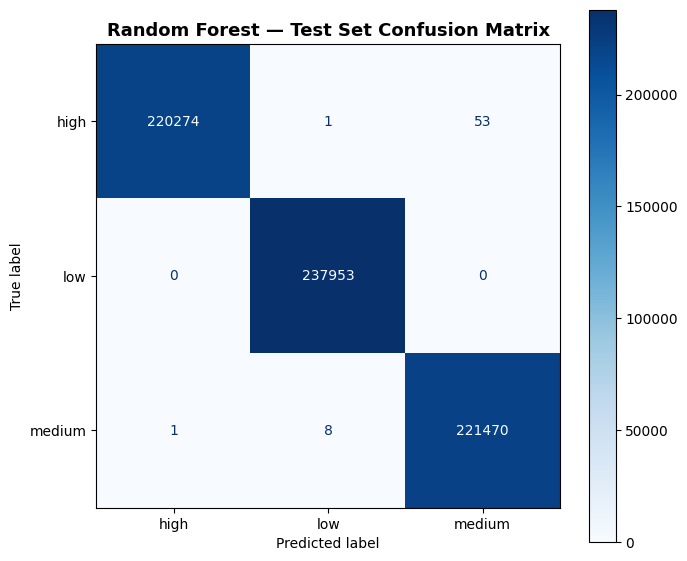

In [47]:
# Confusion matrix plot
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Random Forest — Test Set Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### Save models and data for streamlit app

In [48]:
import pickle
import os

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)

with open("models/dbscan_model.pkl", "wb") as f:
    pickle.dump(dbscan_final, f)

with open("models/rf_model.pkl", "wb") as f:
    pickle.dump(rf_baseline, f)

df["cluster_label"] = -1
df.loc[df_cluster.index, "cluster_label"] = df_cluster["cluster_label"]

features_dict = {
    "df": df,
    "feature_names": RF_FEATURES_CLEAN,
    "scaler": scaler_rf,
    "label_encoder": le,
}

with open("data/features.pkl", "wb") as f:
    pickle.dump(features_dict, f)

print("✅ Saved:")
print("  models/dbscan_model.pkl")
print("  models/rf_model.pkl")
print("  data/features.pkl")

✅ Saved:
  models/dbscan_model.pkl
  models/rf_model.pkl
  data/features.pkl
